# Assignment_1_Association_Variables

Identify the association between dependent and independent variables.


## Aim
Identify the association between an independent variable and a dependent variable using correlation and linear regression.

Result folder: /content/results


,Metric,Value
0,Pearson Correlation,5.864501e-01
1,P-value,3.466006e-42
2,R2 Score,3.439238e-01
3,Coefficient,9.494353e+02
4,Intercept,1.521335e+02


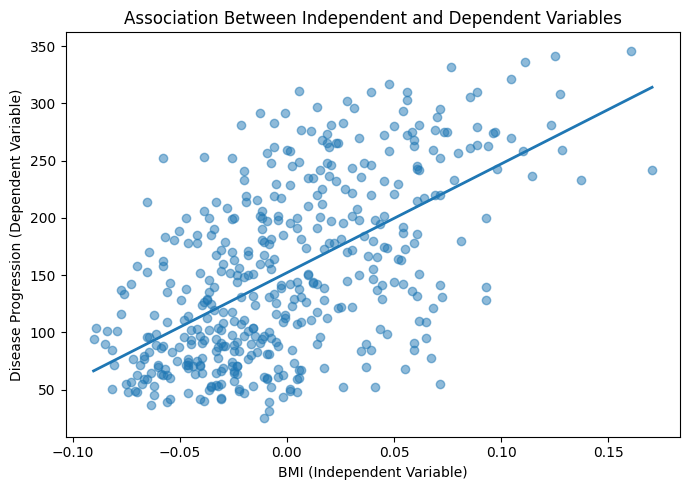

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULT_DIR = "/content/results"
os.makedirs(RESULT_DIR, exist_ok=True)

print("Result folder:", RESULT_DIR)

from sklearn.datasets import load_diabetes
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression

data = load_diabetes(as_frame=True)
df = data.frame
X = df[["bmi"]]
y = df["target"]

corr, p = pearsonr(X["bmi"], y)
model = LinearRegression().fit(X, y)
pred = model.predict(X)

results = pd.DataFrame({
    "Metric":["Pearson Correlation","P-value","R2 Score","Coefficient","Intercept"],
    "Value":[corr,p,model.score(X,y),model.coef_[0],model.intercept_]
})
display(results)

plt.figure(figsize=(7,5))
plt.scatter(X["bmi"], y, alpha=.5)
order = np.argsort(X["bmi"].values)
plt.plot(X["bmi"].values[order], pred[order], linewidth=2)
plt.xlabel("BMI (Independent Variable)")
plt.ylabel("Disease Progression (Dependent Variable)")
plt.title("Association Between Independent and Dependent Variables")
plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/association_plot.png", dpi=150)
plt.show()

results.to_csv(f"{RESULT_DIR}/results.csv", index=False)


In [ ]:
# Download all Assignment 1 results
import shutil
from google.colab import files
shutil.make_archive("/content/Assignment_1_Results", "zip", RESULT_DIR)
files.download("/content/Assignment_1_Results.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>